In [2]:
# Imports
from config import *
import ForwardModel

# Cosmology & Halo Model

In [182]:
importlib.reload(ForwardModel)

model = ForwardModel.Cosmology(VERBOSE=True, PAPERCHECK=True, Models={
  # pyccl should work
  'Cosmology': {'name': 'pyccl', 'h': 0.694, 'Omega_c': 0.25, 'Omega_b': 0.049, 'n_s': 0.965, 'sigma8': 0.811, 'XH':0.76},
  
  'Cosmology': {'name': 'pyccl', 'h': 0.694, 'Omega_c': 0.25, 'Omega_b': 0.049, 'n_s': 0.965, 'sigma8': 0.811, 'XH':0.76},
  # pyccl should work
  'HaloModel': {'name': 'pyccl', 'MassDef':'200c', 'HaloBias':'Tinker10', 'MassFunc': 'Tinker08', 'Concentration':'Diemer15'},
    
  # # astropy in development
  # 'Cosmology': {'name': 'astropy', 'h': 0.694, 'Omega_c': 0.25, 'Omega_b': 0.049, 'n_s': 0.965, 'sigma8': 0.811, 'XH':0.76},
  
  # # colossus in development
  # 'Cosmology': {'name': 'colossus', 'h': 0.694, 'Omega_c': 0.25, 'Omega_b': 0.049, 'n_s': 0.965, 'sigma8': 0.811, 'XH':0.76},
  
  # 'Cosmology': {'name': 'pyccl', 'h': 0.694, 'Omega_c': 0.25, 'Omega_b': 0.049, 'n_s': 0.965, 'sigma8': 0.811, 'XH':0.76},
  # 'HaloModel': {'name': 'colossus', 'MassDef':'200c', 'HaloBias':'Tinker10', 'MassFunc': 'Tinker08', 'Concentration':'Diemer15'},
    },)


Importing pyccl Cosmology from Models.Codes
Initializing with {'h': 0.694, 'Omega_c': 0.25, 'Omega_b': 0.049, 'n_s': 0.965, 'sigma8': 0.811, 'XH': 0.76}

Importing pyccl HaloModel from Models.Codes
Initializing with {'MassDef': '200c', 'HaloBias': 'Tinker10', 'MassFunc': 'Tinker08', 'Concentration': 'Diemer15'}



Hubble Function at z=1: 122.08 km / (Mpc s) 
Angular Distance at z=1: 1667.03 Mpc 
Critical Density at z=1: 2.80e-29 g / cm3 
Comoving Volume at z=1: 1.55e+11 Mpc3


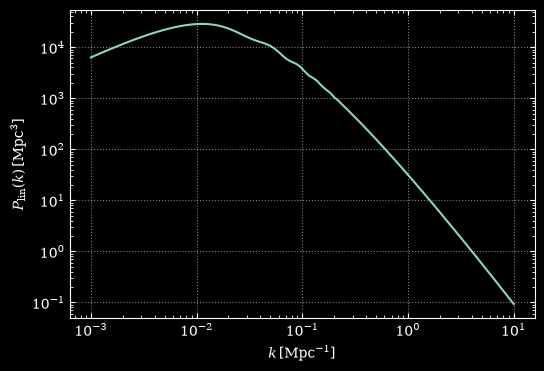

In [183]:
z = 1
print(
  f"\nHubble Function at z={z}: {model.cosmology.H(z):.2f}",
  f"\nAngular Distance at z={z}: {model.cosmology.dA(z):.2f}",
  f"\nCritical Density at z={z}: {model.cosmology.rhoc(z).cgs:.2e}",
  f"\nComoving Volume at z={z}: {model.cosmology.Vcom(z):.2e}",
      )

k = np.logspace(-3, 1, 100)
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.loglog(k, model.cosmology.Plin(k, z)[:, 0], label=f"z={z}")
ax.set(xlabel=r"$k\,[{\rm Mpc}^{-1}]$", ylabel=r"$P_{\rm lin}(k)\,[{\rm Mpc}^3]$")
plt.show()

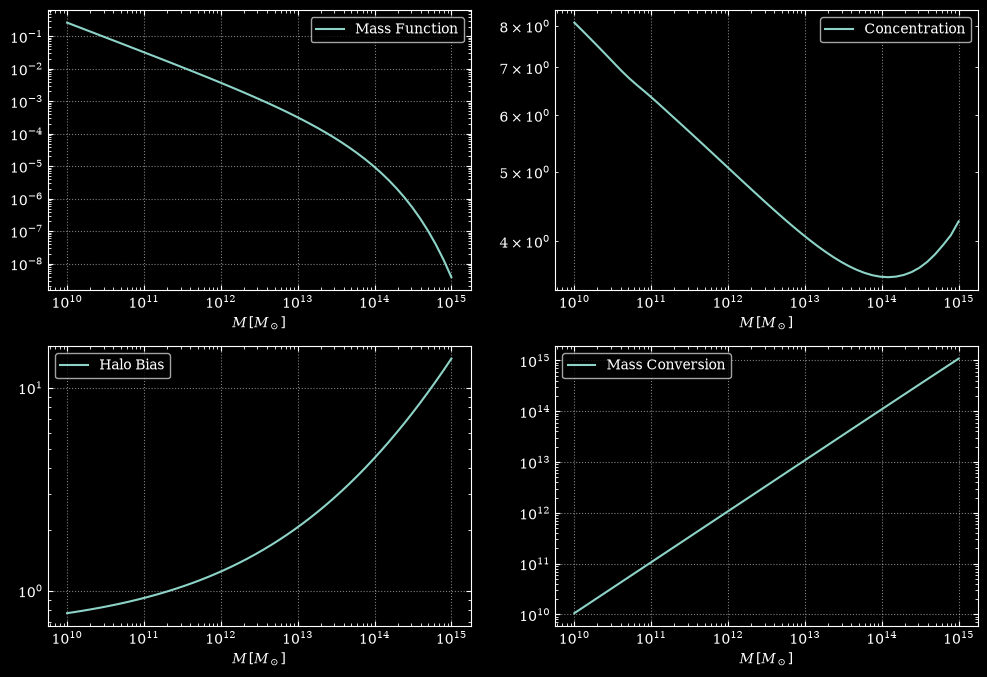

In [184]:
logM = np.linspace(10, 15, 50)

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0,0].loglog(10**logM, model.halomodel.dndlogm(z,logM)[0,:], label="Mass Function")
axs[1,0].loglog(10**logM, model.halomodel.bh(z,logM)[0,:], label="Halo Bias")
axs[0,1].loglog(10**logM, model.halomodel.c(z,logM)[0,:], label="Concentration")
axs[1,1].loglog(10**logM, 10**model.halomodel.logM_conv(z,logM, 'vir')[0,:], label="Mass Conversion")
for ax in axs.flatten():
    ax.set(xlabel=r"$M\,[M_\odot]$")
    ax.legend()
    
plt.show()

# Profile Projection

In [185]:
importlib.reload(ForwardModel)

beam_ells = np.arange(0, 1e4, 1)
FWHM=1.6*u.arcmin
beam = np.exp(-0.5 * (beam_ells * FWHM.to(u.rad).value)**2)

model = ForwardModel.Prof_to_Obs(VERBOSE=True, PAPERCHECK=True, Models={
  'Cosmology': {'name': 'pyccl', 'h': 0.694, 'Omega_c': 0.25, 'Omega_b': 0.049, 'n_s': 0.965, 'sigma8': 0.811, 'XH':0.76},
  
  # No other models are currently implemented
  'CAP': {'name': 'Popik2026'},
  'BeamConvolution': {'name': 'Popik2026'},
  'Projection': {'name': 'Popik2026'},
    },
                  
  # Required parts for the profile to observable process                
  zMean = 0.5,
  R=np.linspace(1, 6, 9)*u.arcmin, 
  beam_ells = beam_ells,
  beam = beam,
  # observable = 'TtSZ', nu=150*u.GHz,
  # observable = 'TkSZ', v_rms=233*u.km/u.s,
  observable = 'y',
  
  )


Importing pyccl Cosmology from Models.Codes
Initializing with {'h': 0.694, 'Omega_c': 0.25, 'Omega_b': 0.049, 'n_s': 0.965, 'sigma8': 0.811, 'XH': 0.76}

Importing Popik2026 CAP from Models.Papers
Initializing with {}

Importing Popik2026 BeamConvolution from Models.Papers
Initializing with {}

Importing Popik2026 Projection from Models.Papers
Initializing with {}
Model: 2.14e-03 Mpc < r < 15.85 Mpc


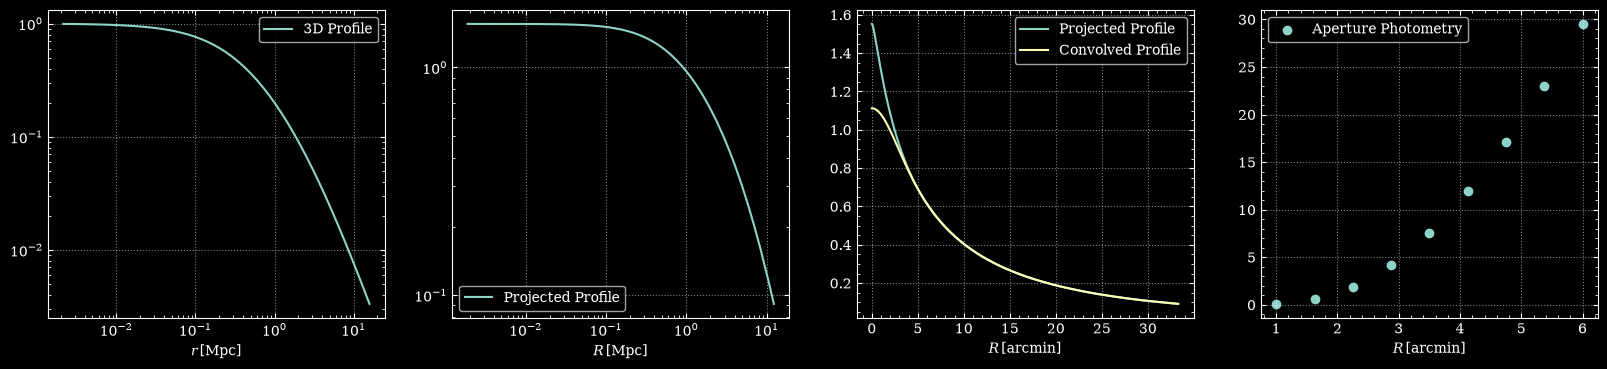

In [186]:
fig, axs = plt.subplots(1, 4, figsize=(20, 4))

prof3d = u.dyne/(model.r/u.Mpc+(1+model.r/u.Mpc)**2)

axs[0].loglog(model.r, prof3d, label='3D Profile')
axs[0].set(xlabel=r"$r\,[{\rm Mpc}]$")

prof2d = model.project_LOS(model.r, prof3d)
axs[1].loglog(model.R_beam.to(u.rad)*model.cosmology.dA(model.zMean), prof2d, label='Projected Profile')
axs[1].set(xlabel=r"$R\,[{\rm Mpc}]$")

axs[2].plot(model.R_beam, prof2d, label='Projected Profile')
R_CAP, prof2d_beam=model.convolve_beam(prof2d)
axs[2].plot(R_CAP, prof2d_beam, label='Convolved Profile')
axs[2].set(xlabel=r"$R\,[{\rm \text{arcmin}}]$")

profCAP = model.aperture_photometry(R_CAP, prof2d_beam)
axs[3].scatter(model.R, profCAP, label='Aperture Photometry')
axs[3].set(xlabel=r"$R\,[{\rm \text{arcmin}}]$")

for ax in axs.flatten(): ax.legend()
plt.show()

# Profile Modeling

In [187]:
importlib.reload(ForwardModel)

model = ForwardModel.ProfileModel(VERBOSE=True, PAPERCHECK=True, Models={
  'Cosmology': {'name': 'pyccl', 'h': 0.694, 'Omega_c': 0.25, 'Omega_b': 0.049, 'n_s': 0.965, 'sigma8': 0.811, 'XH':0.76},

  'HaloModel': {'name': 'pyccl', 'MassDef':'200c', 'HaloBias':'Tinker10', 'MassFunc': 'Tinker08'},
  
  # Popik2026 should work for both density and pressure
  'Density': {'name': 'Popik2026'},
  # 'Pressure': {'name': 'Popik2026'},
  
  # Other models in development
    },
                                  
  zMean = 0.5, 
  r=np.geomspace(1e-2, 1e1, 30)*u.Mpc,
  z=np.linspace(0.1, 1.5, 10),
  logMh=np.linspace(12, 15, 20)
  )


Importing pyccl Cosmology from Models.Codes
Initializing with {'h': 0.694, 'Omega_c': 0.25, 'Omega_b': 0.049, 'n_s': 0.965, 'sigma8': 0.811, 'XH': 0.76}

Importing pyccl HaloModel from Models.Codes
Initializing with {'MassDef': '200c', 'HaloBias': 'Tinker10', 'MassFunc': 'Tinker08'}

Importing Popik2026 Density from Models.Papers
Initializing with {}


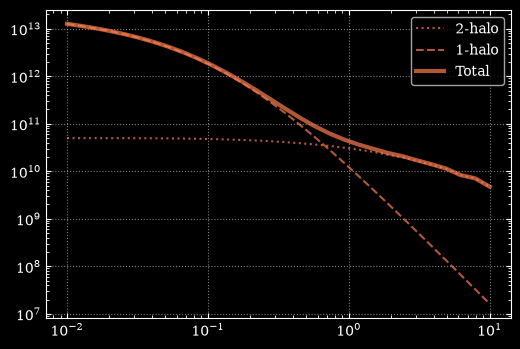

In [188]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax.loglog(model.r, model.prof2h()[:, 0, 0], c='coral', label='2-halo', ls=':', alpha=0.7)
ax.loglog(model.r, model.prof1h()[:, 0, 0], c='coral', label='1-halo', ls='--', alpha=0.7)
ax.loglog(model.r, model.prof()[:, 0, 0], c='coral', label='Total', lw=3, alpha=0.7)

ax.legend()
plt.show()

# Averaging & HOD Model

In [232]:
importlib.reload(ForwardModel)

z = np.linspace(0.1, 1.5, 10)
logMh = np.linspace(12, 15, 20)

model = ForwardModel.Summary_Statistics(
  r=np.geomspace(1e-2, 1e1, 50)*u.Mpc,
  z=z,
  logMh=logMh,
  dNdz = scipy.stats.norm.pdf(z, loc=0.6, scale=0.2),
  dNdlogMh = scipy.stats.norm.pdf(logMh, loc=13.5, scale=0.5),
  
  VERBOSE=True, PAPERCHECK=True, Models={
  'Cosmology': {'name': 'pyccl', 'h': 0.694, 'Omega_c': 0.25, 'Omega_b': 0.049, 'n_s': 0.965, 'sigma8': 0.811, 'XH':0.76},

  'HaloModel': {'name': 'pyccl', 'MassDef':'200c', 'HaloBias':'Tinker10', 'MassFunc': 'Tinker08', 'Concentration':'Diemer15'},
  
  # 'HOD': {'name': 'Yuan2024', 'Tracer':'LRG 0.4<z<0.6', 'Model':'Zheng07+fic'},
  'HOD': {'name': 'Hadzhiyska2025B', 'Sample':'MainLRGs', 'Bin':'all'},
  
  'Spectra': {'name': 'Popik2026'}
    },
  )


Importing pyccl Cosmology from Models.Codes
Initializing with {'h': 0.694, 'Omega_c': 0.25, 'Omega_b': 0.049, 'n_s': 0.965, 'sigma8': 0.811, 'XH': 0.76}

Importing pyccl HaloModel from Models.Codes
Initializing with {'MassDef': '200c', 'HaloBias': 'Tinker10', 'MassFunc': 'Tinker08', 'Concentration': 'Diemer15'}

Importing Hadzhiyska2025B HOD from Models.Papers
Initializing with {'Sample': 'MainLRGs', 'Bin': 'all'}



Importing Popik2026 Spectra from Models.Papers
Initializing with {}


/tmp/ipykernel_2640312/3916106390.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  for ax in axs.flatten(): ax.legend()


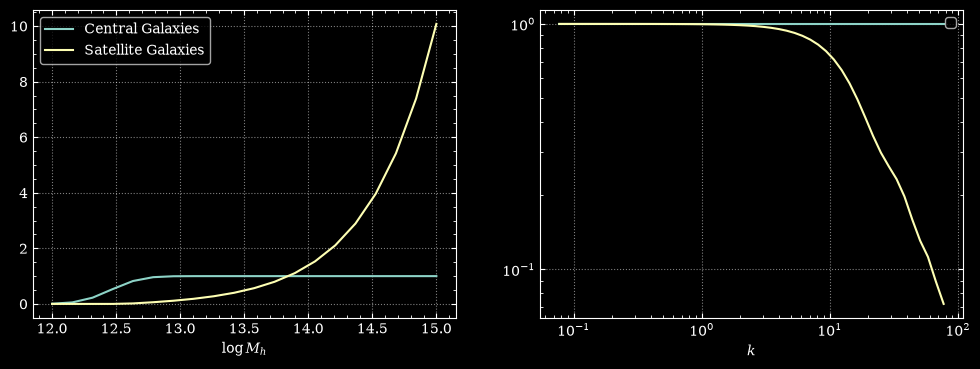

In [233]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(model.logMh, model.Ncen()[0, :], label='Central Galaxies')
axs[0].plot(model.logMh, model.Nsat()[0, :], label='Satellite Galaxies')
axs[0].set(xlabel=r"$\log M_h$")

axs[1].loglog(model.k, model.ucen()[:, 0, 0])
axs[1].loglog(model.k, model.usat()[:, 0, 0])
axs[1].set(xlabel=r"$k$")

for ax in axs.flatten(): ax.legend()
plt.show()

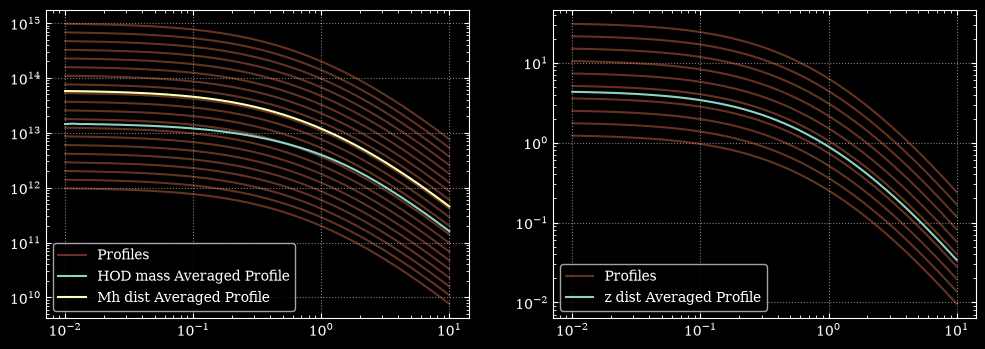

In [234]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

prof3d = 10**model.logMh*u.dyne/(model.r/u.Mpc+(1+model.r/u.Mpc)**2)[:, None, None]

for i in range(model.logMh.size):
    label = 'Profiles' if i==0 else None
    axs[0].loglog(model.r, prof3d[:, 0, i], alpha=0.4, c='coral', label=label)

profave_hod = model.ave_hod(prof3d)
axs[0].loglog(model.r, profave_hod[:, 0], label='HOD mass Averaged Profile')
profave_dndm = model.ave_Mh(prof3d)
axs[0].loglog(model.r, profave_dndm[:, 0], label='Mh dist Averaged Profile')

prof3d = 10**model.z*u.dyne/(model.r/u.Mpc+(1+model.r/u.Mpc)**2)[:, None]
for i in range(model.z.size):
    label = 'Profiles' if i==0 else None
    axs[1].loglog(model.r, prof3d[:, i], alpha=0.4, c='coral', label=label)
    
profave_dndm = model.ave_z(prof3d)
axs[1].loglog(model.r, profave_dndm, label='z dist Averaged Profile')


axs[0].legend(); axs[1].legend()
plt.show()

# Mass/Redshift Distribution

In [323]:
importlib.reload(ForwardModel)

model = ForwardModel.Target_Distributions(VERBOSE=True, PAPERCHECK=True, Models={
  'Cosmology': {'name': 'pyccl', 'h': 0.694, 'Omega_c': 0.25, 'Omega_b': 0.049, 'n_s': 0.965, 'sigma8': 0.811, 'XH':0.76},
  
  'HaloModel': {'name': 'pyccl', 'MassDef':'200c', 'Concentration':'Diemer15'},
  
  # # RG25 requires halomodel and SHMR for conversions
  # 'TargetData': {'name': 'RiedGuachalla2025', 'bin':'z_4',
  #                'logMhNum':30,'logMhMax':15,
  #                'zNum': 10},
  # 'SHMR': {'name': 'Gao2023', 'model':'Psat', 'Concentration': 'Duffy08'},
       
  # L25 doesn't have halo mass so that needs to be defined
  'TargetData': {'name': 'Liu2025', 'zbin':'z1', 
                 'logMhNum':10, 'logMhMin':12, 'logMhMax':15,
                 'zNum': 100},
  },                            
  )


Importing pyccl Cosmology from Models.Codes
Initializing with {'h': 0.694, 'Omega_c': 0.25, 'Omega_b': 0.049, 'n_s': 0.965, 'sigma8': 0.811, 'XH': 0.76}

Importing pyccl HaloModel from Models.Codes
Initializing with {'MassDef': '200c', 'Concentration': 'Diemer15'}

Importing Liu2025 TargetData from Models.Papers
Initializing with {'zbin': 'z1', 'logMhNum': 10, 'logMhMin': 12, 'logMhMax': 15, 'zNum': 100}
Paper: nan < z < nan, zMean = 0.47
Model: 0.01 < z < 1.48, zMean = 0.47, dz = 0.01
Paper: nan < logMh < nan, logMhMean = 13.40
Model: 12.00 < logMh < 15.00, logMhMean = 13.40, dlogMh = 0.33


/tmp/ipykernel_2640312/2628858981.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  for ax in axs.flatten(): ax.legend()


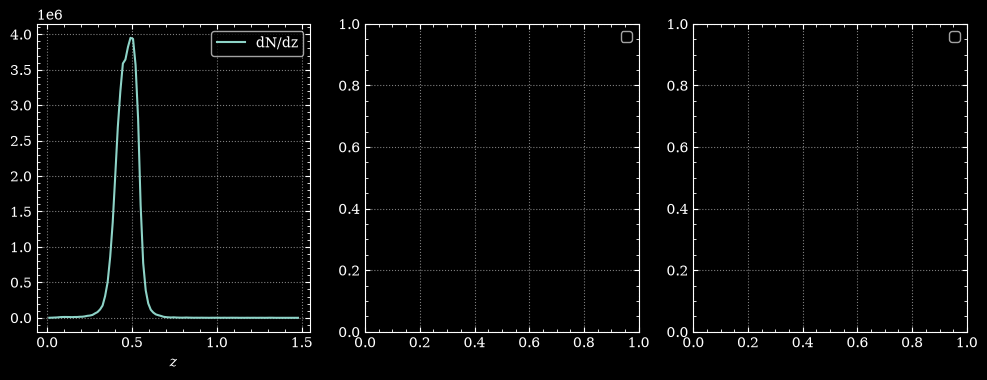

In [324]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].plot(model.z, model.dNdz, label='dN/dz')
axs[0].set(xlabel=r"$z$")

try:
    axs[1].plot(model.logMs, model.dNdlogMs, label='dN/dlogMs')
    axs[1].set(xlabel=r"$\log M_s$")
except: pass

try:
    axs[2].plot(model.logMh, model.dNdlogMh, label='dN/dlogMh')
    axs[2].set(xlabel=r"$\log M_h$")
except: pass

for ax in axs.flatten(): ax.legend()
plt.show()

# Combined

In [342]:
importlib.reload(ForwardModel)

model = ForwardModel.SZObservable(VERBOSE=True, PAPERCHECK=True, Models={
  'Cosmology': {'name': 'pyccl', 'h': 0.694, 'Omega_c': 0.25, 'Omega_b': 0.049, 'n_s': 0.965, 'sigma8': 0.811, 'XH':0.76},

  'HaloModel': {'name': 'pyccl', 'MassDef':'200c', 'HaloBias':'Tinker10', 'MassFunc': 'Tinker08', 'Concentration':'Diemer15'},
  
  'MapData': {'name': 'Coulton2024'},
  'Spectra': {'name': 'Popik2026'},
  'CAP': {'name': 'Popik2026'},
  'BeamConvolution': {'name': 'Popik2026'},
  'Projection': {'name': 'Popik2026'},
  
  # # 'SHMR': {'name': 'Gao2023', 'model':'Psat', 'Concentration': 'Duffy08'},
  # 'Measurement': {'name': 'RiedGuachalla2025', 'bin':'all'},
  # 'TargetData': {'name': 'RiedGuachalla2025', 'bin':'all',
  #                'zNum': 5, 'logMhNum': 10, 'logMhMin': 12, 'logMhMax': 15},
  # 'HOD': {'name': 'Hadzhiyska2025B', 'Sample':'MainLRGs', 'Bin':'all'},
  # 'Density': {'name': 'Popik2026'},
  
  'Measurement': {'name': 'Liu2025', 'zbin':'z1', 'ACTDR':'DR6', 'dp':'dBeta', 'TCIB':'10.7', 'Beta':'fiducial'},
  'TargetData': {'name': 'Liu2025', 'zbin':'z1',
                 'zNum': 10, 'logMhNum': 25, 'logMhMin': 12, 'logMhMax': 15},
  'HOD': {'name': 'Hadzhiyska2025B', 'Sample':'MainLRGs', 'Bin':'z1'},
  'Pressure': {'name': 'Popik2026'},

    },
  )


Importing pyccl Cosmology from Models.Codes
Initializing with {'h': 0.694, 'Omega_c': 0.25, 'Omega_b': 0.049, 'n_s': 0.965, 'sigma8': 0.811, 'XH': 0.76}

Importing pyccl HaloModel from Models.Codes
Initializing with {'MassDef': '200c', 'HaloBias': 'Tinker10', 'MassFunc': 'Tinker08', 'Concentration': 'Diemer15'}

Importing Liu2025 Measurement from Models.Papers
Initializing with {'zbin': 'z1', 'ACTDR': 'DR6', 'dp': 'dBeta', 'TCIB': '10.7', 'Beta': 'fiducial'}

Importing Liu2025 TargetData from Models.Papers
Initializing with {'zbin': 'z1', 'zNum': 10, 'logMhNum': 25, 'logMhMin': 12, 'logMhMax': 15}
Paper: nan < z < nan, zMean = 0.47
Model: 0.09 < z < 1.40, zMean = 0.44, dz = 0.16
Paper: nan < logMh < nan, logMhMean = 13.40
Model: 12.00 < logMh < 15.00, logMhMean = 13.40, dlogMh = 0.12

Importing Coulton2024 MapData from Models.Papers
Initializing with {}

Importing Popik2026 CAP from Models.Papers
Initializing with {}

Importing Popik2026 BeamConvolution from Models.Papers
Initializing

/tmp/ipykernel_2640312/1135635710.py:22: RuntimeWarning: divide by zero encountered in divide
  axs[1].loglog(np.pi/model.beam_ells*u.rad.to(u.arcmin), model.beam[::-1]*aveprof2D.max()*10, ls='-', color='lime', label='Beam (scaled)')


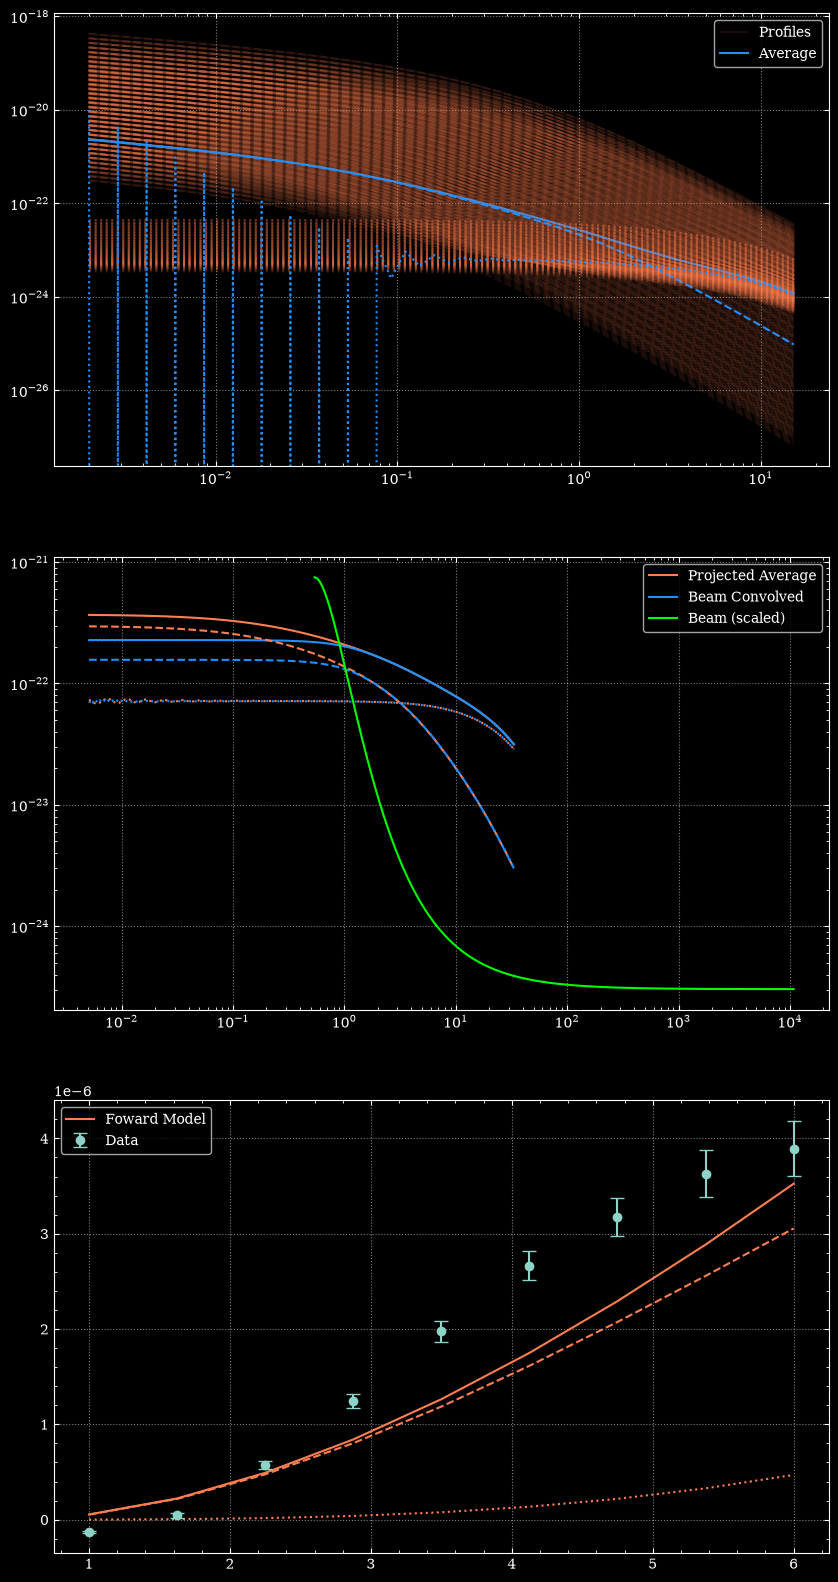

In [343]:
fig, axs = plt.subplots(3, 1, figsize=(10, 20))

for prof3D, label, ls in zip([model.prof(), model.prof1h(), model.prof2h()], ['Total', '1-halo', '2-halo'], ['-', '--', ':']):

    for i in range(prof3D.shape[2]):
        for j in range(prof3D.shape[1]):
            axs[0].loglog(model.r, prof3D[:, j, i], alpha=0.1, ls=ls, color='coral', label='Profiles' if (label=='Total' and i==0 and j==0) else None)

    aveprof3D = model.average_prof(prof3D)
    axs[0].loglog(model.r, aveprof3D, ls=ls, color='dodgerblue', label='Average' if label=='Total' else None)

    aveprof2D = model.project_LOS(model.r, aveprof3D)
    axs[1].loglog(model.R_beam, aveprof2D, ls=ls, color='coral', label='Projected Average' if label=='Total' else None)

    Rbeam, beamprof2D = model.convolve_beam(aveprof2D)
    axs[1].loglog(Rbeam, beamprof2D, ls=ls, color='dodgerblue', label='Beam Convolved' if label=='Total' else None)

    profCAP = model.aperture_photometry(Rbeam, beamprof2D)
    axs[2].plot(model.R, model.profunit_to_obsunit*profCAP, ls=ls, color='coral', label='Foward Model' if label=='Total' else None)
    
# axs[1].loglog(Rbeam, model.beamconv.rht.unpad(model.beamconv.beamTF)*aveprof2D.max()*10, ls='-', color='lime', label='Beam (scaled)')
axs[1].loglog(np.pi/model.beam_ells*u.rad.to(u.arcmin), model.beam[::-1]*aveprof2D.max()*10, ls='-', color='lime', label='Beam (scaled)')

axs[2].errorbar(model.R, model.meas_data, model.meas_err, fmt='o', capsize=5, label='Data')
    
if model.observable=='TkSZ': axs[2].set(yscale='log')

for ax in axs.flatten(): ax.legend()
plt.show()

In [272]:
timestats = model.test_time(n_trials=10000)

onehalo                mean= 201.315 us  std= 701.378 us  min= 105.459 us  max=28220.149 us
twohalo                mean=  16.713 us  std= 198.519 us  min=   8.275 us  max=15512.104 us
ave_hod                mean=3723.867 us  std=3294.494 us  min=2448.477 us  max=48440.929 us
ave_z                  mean=  95.157 us  std= 402.428 us  min=  58.623 us  max=19861.612 us
project_LOS            mean= 670.745 us  std=1248.193 us  min= 417.473 us  max=33521.251 us
convolve_beam          mean= 721.304 us  std=1184.732 us  min= 455.135 us  max=24766.784 us
aperture_photometry    mean= 298.173 us  std= 637.964 us  min= 189.135 us  max=27595.268 us
unit_conversion        mean=  55.986 us  std= 279.850 us  min=  32.342 us  max=17577.609 us


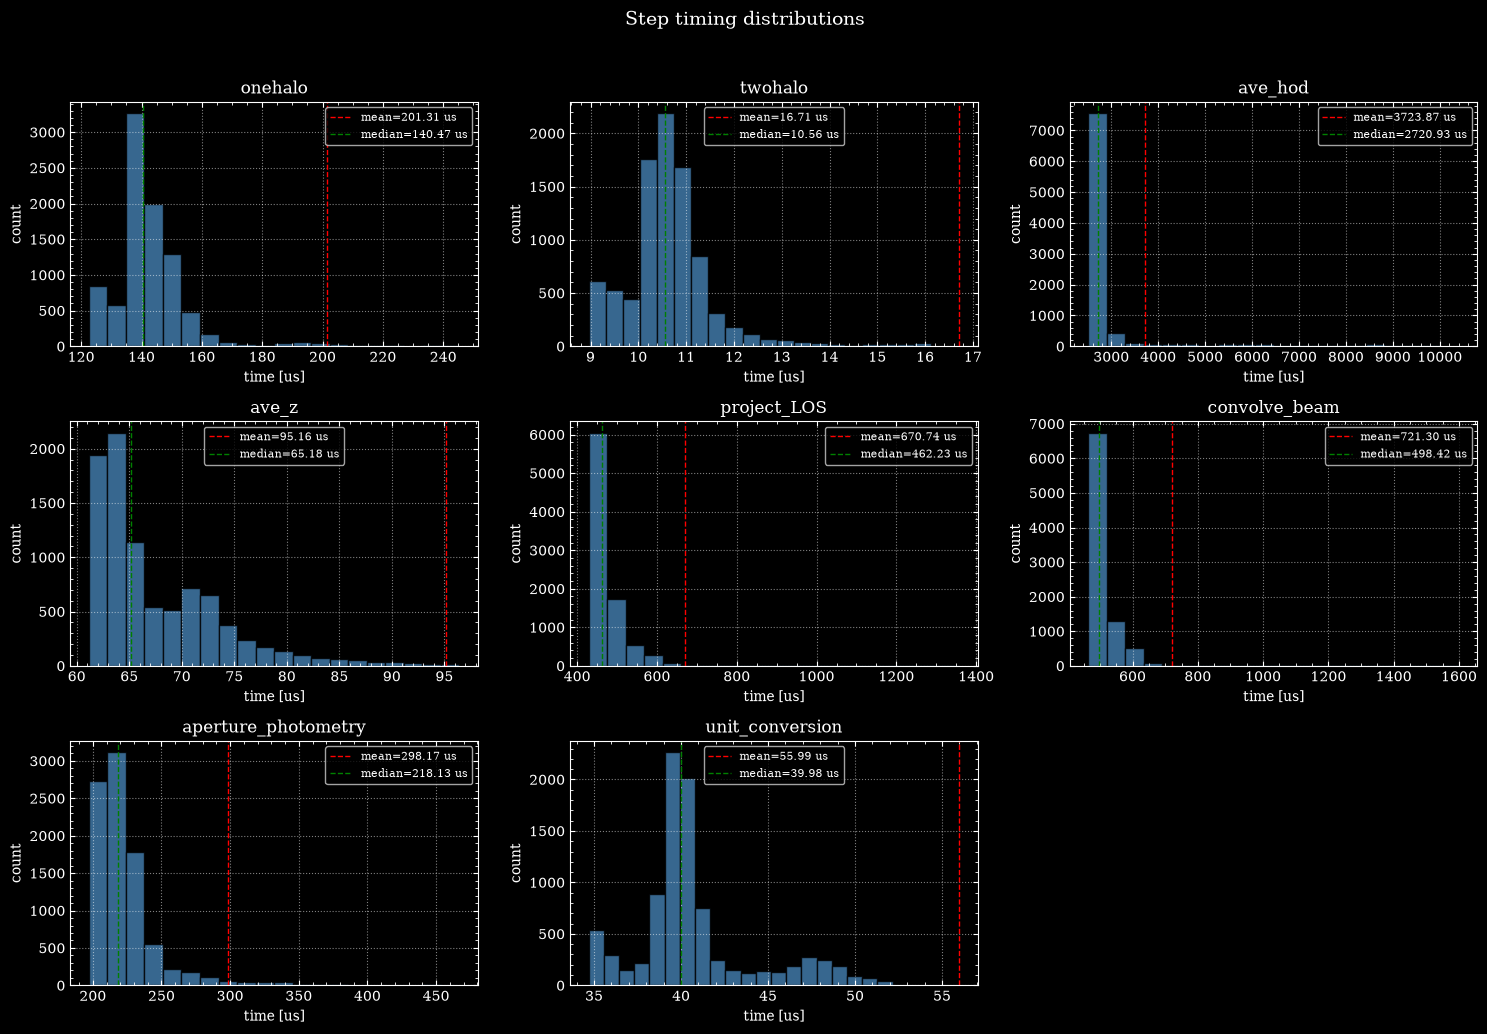

In [273]:
model.plot_test_time(timestats, bins=20, percentiles=(5, 95))